In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
#from sklearn.decomposition import PCA
#from sklearn.neighbors import NearestNeighbors
#import igraph as ig
#import leidenalg as la
#from umap.umap_ import fuzzy_simplicial_set
#import umap
import os
import math
#import pickle
from natsort import natsorted
from pathlib import Path

import anndata as ad
import warnings
warnings.filterwarnings('ignore')
#import tensorflow as tf


import sys
import pickle

#sys.path.append('/home/mystique/Banksy_py')
#sys.path.append('/home/mystique/Banksy_py/banksy')
#sys.path.append('/home/mystique/Banksy_py/banksy_utils')


sys.path.append('/home/shamini_pathomics_io/Banksy_py')
sys.path.append('/home/shamini_pathomics_io/Banksy_py/banksy')
sys.path.append('/home/shamini_pathomics_io/Banksy_py/banksy_utils')


In [50]:
home_dir = Path.home()

dst_folder = home_dir / 'ext_hd_sammy' / 'projects' / 'out' / 'out_stomics' / 'script04_output'
os.makedirs(dst_folder, exist_ok=True)

In [2]:
sc = sc.read_h5ad('/mnt/disks/ext_hd_sammy/data/single_cell/cxgene_serous_ovarian.h5ad')

In [3]:
sc.uns['schema_reference']

'https://github.com/chanzuckerberg/single-cell-curation/blob/main/schema/6.0.0/schema.md'

In [38]:
meta_to_keep = [
 'author_sample_id',
 'author_cell_type',
 'cell_type_ontology_term_id',
 'tissue_ontology_term_id',
 'assay_ontology_term_id',
 'suspension_type',
 'disease_ontology_term_id',
 'self_reported_ethnicity_ontology_term_id',
 'development_stage_ontology_term_id',
 'sex_ontology_term_id',
 'donor_id',
 'author_tumor_supersite',
 'author_tumor_site',
 'author_tumor_subsite',
 'author_sort_parameters',
 'author_therapy',
 'author_procedure',
 'author_procedure_type',
 'is_primary_data',
 'tissue_type',
 'cell_type',
 'assay',
 'disease',
 'sex',
 'tissue',
 'self_reported_ethnicity',
 'development_stage',
 ]


In [59]:
import json

meta_dict = sc.obs[meta_to_keep].agg(lambda x: x.unique().tolist()).to_dict()

with open(dst_folder / "meta_unique_values.json", "w") as f:
    json.dump(meta_dict, f, indent=2)

In [4]:
ad = ad.read_h5ad('/home/shamini_pathomics_io/ext_hd_sammy/projects/out/out_stomics/script03_output/banksy_results_B04101E6_scanpy_adata.h5ad')


In [5]:
ad.obs

,dnbCount,area,orig.ident,x,y,sample_id,ncounts,ngenes,n_genes,n_counts,leiden,PTPRC,labels_nonspatial_pc21_nc0.00_r0.15,labels_scaled_gaussian_pc21_nc0.80_r0.15
24339579670964,82,400,sample,5667,4532,B04101E6_scanpy,123,110,110,123,193,-0.021531,27,3
44289702759429,91,448,sample,10312,3077,B04101E6_scanpy,123,104,104,123,95,-0.021531,0,18
30528627545200,93,369,sample,7108,5232,B04101E6_scanpy,126,114,114,126,147,-0.021531,27,26
28402618736048,92,375,sample,6613,7600,B04101E6_scanpy,124,111,111,124,145,-0.021531,27,1
47055661702979,91,340,sample,10956,8003,B04101E6_scanpy,125,113,113,125,68,-0.021531,27,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53218939769830,56,180,sample,12391,5094,B04101E6_scanpy,84,75,75,84,14,10.000000,0,9
24021752092133,109,589,sample,5593,5605,B04101E6_scanpy,151,133,133,151,56,10.000000,0,9
50281182137346,102,606,sample,11707,3074,B04101E6_scanpy,135,122,122,135,97,10.000000,0,9
51522427692659,119,574,sample,11996,9843,B04101E6_scanpy,159,143,143,159,24,10.000000,0,9


<Axes: xlabel='x', ylabel='y'>

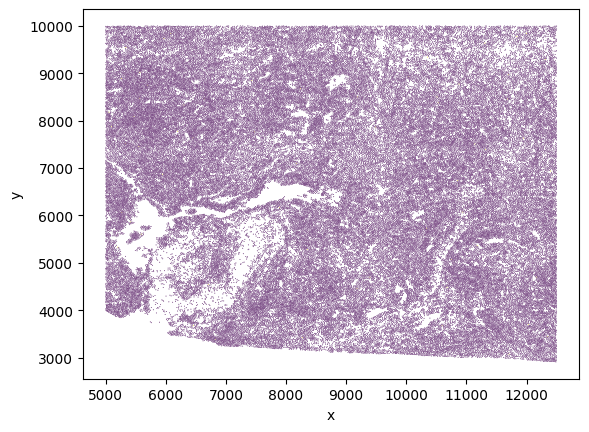

In [29]:
ad.obs = ad.obs.sort_values(by='PTPRC', ascending=False)
sns.scatterplot(data=ad.obs, x='x', y='y', hue='PTPRC', alpha=1, s=.45, legend=None, palette='viridis')